# 01 — Exploratory Data Analysis

Validate the supplied WDBC data, inspect class balance, duplicates and distributions.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
FEATURE_BASE = ['radius','texture','perimeter','area','smoothness','compactness','concavity','concave_points','symmetry','fractal_dimension']
FEATURES = [f'{stat}_{feat}' for stat in ['mean','se','worst'] for feat in FEATURE_BASE]
path='data/wdbc.data'
df=pd.read_csv(path,header=None,names=['id','diagnosis']+FEATURES)
print('Shape:', df.shape)
df.head()

Shape: (569, 32)


,id,diagnosis,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,se_radius,se_texture,se_perimeter,se_area,se_smoothness,se_compactness,se_concavity,se_concave_points,se_symmetry,se_fractal_dimension,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [2]:
print('Missing values:', int(df.isna().sum().sum()))
print('Duplicate rows:', int(df.duplicated().sum()))
print('Duplicate IDs:', int(df['id'].duplicated().sum()))
print('Class counts:\n', df['diagnosis'].value_counts())
print('Class percentages:\n', (df['diagnosis'].value_counts(normalize=True)*100).round(2))

Missing values: 0
Duplicate rows: 0
Duplicate IDs: 0
Class counts:
 diagnosis
B    357
M    212
Name: count, dtype: int64
Class percentages:
 diagnosis
B    62.74
M    37.26
Name: proportion, dtype: float64


In [3]:
df[FEATURES].describe().T[['mean','std','min','max']].head(10)

,mean,std,min,max
mean_radius,14.127292,3.524049,6.98100,28.11000
mean_texture,19.289649,4.301036,9.71000,39.28000
mean_perimeter,91.969033,24.298981,43.79000,188.50000
mean_area,654.889104,351.914129,143.50000,2501.00000
mean_smoothness,0.096360,0.014064,0.05263,0.16340
mean_compactness,0.104341,0.052813,0.01938,0.34540
mean_concavity,0.088799,0.079720,0.00000,0.42680
mean_concave_points,0.048919,0.038803,0.00000,0.20120
mean_symmetry,0.181162,0.027414,0.10600,0.30400
mean_fractal_dimension,0.062798,0.007060,0.04996,0.09744


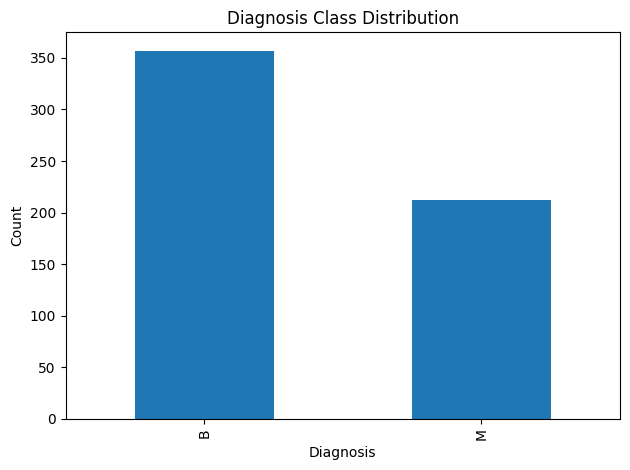

In [4]:
ax=df['diagnosis'].value_counts().sort_index().plot(kind='bar',title='Diagnosis Class Distribution'); ax.set_xlabel('Diagnosis'); ax.set_ylabel('Count'); plt.tight_layout(); plt.show()